# Assignment 3: Machine Learning (CSE343/CSE543)
## Instructions
## ✅ Rename the filename with your roll number. E.g. if your roll number is `MT22018` then rename the file `MT22018_a3.ipynb` before submitting.
## ✅ Write code only in the sections marked with `### YOUR CODE HERE`. No, you can NOT write code anywhere else.
## ✅ Do NOT install or import any other libraries beyond what is imported below.
## ❌ Do not modify any other function or class definitions; doing so may lead to the autograder failing to judge your submission, resulting in a zero.
## ❌ Deleting or adding new cells may lead to the autograder failing to judge your submission, resulting in a zero. Even if a cell is empty, do NOT delete it.
## ❌ Do NOT use sklearn for implementing the core algorithms in Q1 (cross-validation loop), Q3 (neural network), or Q4 (SVM). sklearn is allowed only for data generation and metrics.

**Total Marks: 14**
- Q1: K-Fold Cross-Validation (3 marks)
- Q2: Bias-Variance Tradeoff (2 marks)
- Q3: Neural Network from Scratch (5 marks)
- Q4: Support Vector Machine (4 marks)

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---

# Q1: K-Fold Cross-Validation from Scratch (3 marks)

Implement k-fold cross-validation **without using sklearn's KFold or cross_val_score**. You may use sklearn models as classifiers but the splitting and CV loop logic must be yours.

### Part A (1 mark): `create_folds`
Implement a function that splits data indices into k folds. Each sample must appear in exactly one validation fold.

### Part B (1 mark): `run_cv`
Implement a function that performs k-fold CV given a model, data, and k. Returns a dictionary with per-fold scores and summary statistics.

### Part C (1 mark): `create_stratified_folds`
Same as Part A but preserves the class distribution in each fold. For an imbalanced dataset, each fold should have approximately the same class ratio as the full dataset (within ±5%).

In [86]:
def create_folds(X, y, k):
    """
    Split dataset indices into k folds.

    Args:
        X: numpy array of shape (n_samples, n_features)
        y: numpy array of shape (n_samples,)
        k: int, number of folds

    Returns:
        folds: list of k tuples (train_indices, val_indices)
               where each is a numpy array of indices
    """
    ### YOUR CODE HERE
    n_samples=X.shape[0]
    indices=np.random.permutation(n_samples)
    val_splits=np.array_split(indices, k)
    
    folds=[]
    for i in range(k):
        val_indices=val_splits[i]
        train_indices=np.concatenate(val_splits[:i]+val_splits[i+1:])
        folds.append((train_indices, val_indices))
    return folds


def run_cv(model_class, X, y, k=5):
    """
    Perform k-fold cross-validation.

    Args:
        model_class: a sklearn-compatible model instance (has fit/predict)
        X: numpy array (n_samples, n_features)
        y: numpy array (n_samples,)
        k: int, number of folds

    Returns:
        dict with keys:
            'fold_scores': list of k float accuracy scores
            'mean_score': float, mean of fold scores
            'std_score': float, std of fold scores
    """
    ### YOUR CODE HERE
    folds=create_folds(X, y, k)
    fold_scores=[]
    
    for train_idx, val_idx in folds:
        model=clone(model_class)
        model.fit(X[train_idx], y[train_idx])
        y_pred=model.predict(X[val_idx])
        fold_scores.append(accuracy_score(y[val_idx], y_pred))
    
    dict_cv = {
        'fold_scores': fold_scores,
        'mean_score': float(np.mean(fold_scores)),
        'std_score': float(np.std(fold_scores))
    }
    return dict_cv


def create_stratified_folds(X, y, k):
    """
    Split dataset into k stratified folds (class proportions preserved).

    Args:
        X: numpy array (n_samples, n_features)
        y: numpy array (n_samples,)
        k: int, number of folds

    Returns:
        folds: list of k tuples (train_indices, val_indices)
    """
    ### YOUR CODE HERE
    unique_cls=np.unique(y)
    cls_splits={}
    
    for cls in unique_cls:
        cls_indices=np.where(y == cls)[0]
        cls_indices=np.random.permutation(cls_indices)
        cls_splits[cls]=np.array_split(cls_indices, k)
    
    val_folds=[]
    for i in range(k):
        fold_parts=[]
        for cls in unique_cls:
            fold_parts.append(cls_splits[cls][i])
        if(len(fold_parts)>0):
            val_indices=np.concatenate(fold_parts)
        else:
            val_indices=np.array([], dtype=int)
        val_indices=np.random.permutation(val_indices)
        val_folds.append(val_indices)
    
    all_indices=np.arange(X.shape[0])
    folds=[]
    for i in range(k):
        val_indices=val_folds[i]
        train_msk=np.ones(X.shape[0], dtype=bool)
        train_msk[val_indices]=False
        train_indices=all_indices[train_msk]
        folds.append((train_indices, val_indices))
    
    return folds

In [87]:
# DO NOT MODIFY — Autograder test for Q1 Part A

In [88]:
# DO NOT MODIFY — Autograder test for Q1 Part B

In [89]:
# DO NOT MODIFY — Autograder test for Q1 Part C (Stratified)

# Q2: Bias-Variance Tradeoff (2 marks)

Implement the bootstrap-based bias-variance decomposition for regression.

**Background:** For a regression model, the expected prediction error can be decomposed as:
$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$

Where:
- $\text{Bias}^2 = \frac{1}{n}\sum_i (\bar{f}(x_i) - y_i)^2$ where $\bar{f}(x_i)$ is the mean prediction across bootstraps
- $\text{Variance} = \frac{1}{n}\sum_i \text{Var}[\hat{f}(x_i)]$ across bootstrap predictions
- $\text{Total Error} = \frac{1}{n}\sum_i \mathbb{E}[(\hat{f}(x_i) - y_i)^2]$ averaged across bootstraps

### Part A (1 mark): `bootstrap_train_predict`
Train a model on multiple bootstrap samples and collect predictions on a fixed test set.

### Part B (1 mark): `compute_bias_variance`
Compute the bias², variance, and total error from the predictions matrix.

After implementing both, plot bias² and variance vs polynomial degree (1 to 15) — this plot is for your understanding and is NOT graded.

In [90]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline


def bootstrap_train_predict(model_class, X_train, y_train, X_test, n_bootstraps=50):
    """
    Train model on bootstrap samples, predict on fixed test set.

    Args:
        model_class: sklearn model instance (will be cloned for each bootstrap)
        X_train: (n_train, n_features)
        y_train: (n_train,)
        X_test: (n_test, n_features)
        n_bootstraps: int

    Returns:
        predictions: numpy array of shape (n_bootstraps, n_test_samples)
    """
    ### YOUR CODE HERE
    n_train=X_train.shape[0]
    predictions=[]
    for _ in range(n_bootstraps):
        sample_indices=np.random.choice(n_train, size=n_train, replace=True)
        model=clone(model_class)
        model.fit(X_train[sample_indices], y_train[sample_indices])
        predictions.append(model.predict(X_test))
    return np.array(predictions)


def compute_bias_variance(predictions, y_test):
    """
    Compute bias-variance decomposition from predictions matrix.

    Args:
        predictions: numpy array of shape (n_bootstraps, n_test_samples)
        y_test: numpy array of shape (n_test_samples,)

    Returns:
        dict with keys:
            'bias_squared': float
            'variance': float
            'total_error': float
    """
    ### YOUR CODE HERE
    mean_pred=np.mean(predictions, axis=0)
    bias_squared=np.mean((mean_pred - y_test) ** 2)
    variance=np.mean(np.var(predictions, axis=0))
    total_error=np.mean((predictions - y_test.reshape(1, -1))**2)
    return {
        'bias_squared': float(bias_squared),
        'variance': float(variance),
        'total_error': float(total_error)
    }

In [91]:
# DO NOT MODIFY — Autograder test for Q2 Part A

In [92]:
# DO NOT MODIFY — Autograder test for Q2 Part B

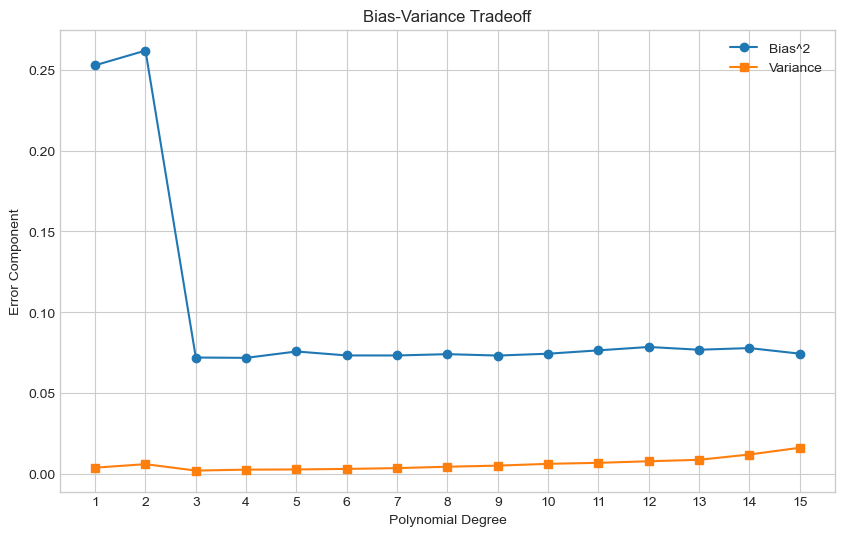

In [93]:
# Plot bias-variance tradeoff for polynomial degrees 1-15
# This cell is for your understanding and is NOT graded

### YOUR CODE HERE
np.random.seed(42)
X=np.linspace(-3, 3, 250).reshape(-1, 1)
y=np.sin(X).ravel() + 0.3 * np.random.randn(X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees=range(1, 16)
bias_values=[]
variance_values=[]

for degree in degrees:
    model=make_pipeline(PolynomialFeatures(degree), LinearRegression())
    preds=bootstrap_train_predict(model, X_train, y_train, X_test, n_bootstraps=80)
    bv=compute_bias_variance(preds, y_test)
    bias_values.append(bv['bias_squared'])
    variance_values.append(bv['variance'])

plt.figure(figsize=(10, 6))
plt.plot(degrees, bias_values, marker='o', label='Bias^2')
plt.plot(degrees, variance_values, marker='s', label='Variance')
plt.xlabel('Polynomial Degree')
plt.ylabel('Error Component')
plt.title('Bias-Variance Tradeoff')
plt.xticks(list(degrees))
plt.legend()
plt.show()

# Q3: Neural Network from Scratch (5 marks)

Implement a feedforward neural network using **only NumPy**. No PyTorch, TensorFlow, or sklearn neural network classes allowed.

**Architecture Requirements:**
- Configurable hidden layers via `layer_dims` parameter (e.g., `[2, 64, 32, 1]`)
- ReLU activation for hidden layers
- Sigmoid activation for output layer (binary classification)
- Binary Cross-Entropy loss
- Full-batch gradient descent

**Grading Breakdown:**
1. Weight initialization & shapes (0.5 marks)
2. Forward pass (1 mark)
3. Backpropagation — gradient computation (1.5 marks)
4. Training loop (0.5 marks)
5. Accuracy on `make_moons` dataset (1.5 marks) — bracket grading:

| Accuracy | Score |
|----------|-------|
| > 93%    | 1.5/1.5 (0.5 + 0.5 + 0.5) |
| 88–93%   | 1.0/1.5 (0.5 + 0.5)       |
| 82–88%   | 0.5/1.5 (0.5)             |
| < 82%    | 0/1.5                     |

**Mathematical Reference:**

Forward pass:
$Z^{[l]} = W^{[l]T} A^{[l-1]} + b^{[l]}$
$A^{[l]} = g^{[l]}(Z^{[l]})$

where $g$ is ReLU for hidden layers and Sigmoid for the output layer.

Binary Cross-Entropy Loss:
$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$

Backpropagation (output layer):
$dZ^{[L]} = A^{[L]} - Y$
$dW^{[L]} = \frac{1}{m} dZ^{[L]} A^{[L-1]T}$
$db^{[L]} = \frac{1}{m} \sum dZ^{[L]}$

Backpropagation (hidden layers):
$dA^{[l]} = W^{[l+1]} dZ^{[l+1]}$
$dZ^{[l]} = dA^{[l]} * g'^{[l]}(Z^{[l]})$

In [94]:
class NeuralNetwork:
    """
    Feedforward Neural Network for binary classification.
    Uses only NumPy. ReLU hidden activations, Sigmoid output.
    """

    def __init__(self, layer_dims):
        """
        Args:
            layer_dims: list of ints, e.g. [2, 64, 32, 1]
                        first element = input features
                        last element = output (1 for binary classification)
        """
        ### YOUR CODE HERE
        self.layer_dims=layer_dims
        self.num_layers=len(layer_dims)-1
        self.params={}
        for layer_no in range(1, self.num_layers+1):
            in_size=layer_dims[layer_no-1]
            out_size=layer_dims[layer_no]
            self.params[f'W{layer_no}']=np.random.randn(in_size, out_size)*0.7*np.sqrt(2.0/in_size)
            self.params[f'b{layer_no}']=np.zeros((1, out_size))
        self._cache = {}

    def _relu(self, Z):
        """ReLU activation."""
        ### YOUR CODE HERE
        return np.maximum(0, Z)

    def _relu_derivative(self, Z):
        """Derivative of ReLU."""
        ### YOUR CODE HERE
        return (Z > 0).astype(float)

    def _sigmoid(self, Z):
        """Sigmoid activation."""
        ### YOUR CODE HERE
        return 1 / (1 + np.exp(-Z))

    def forward(self, X):
        """
        Forward pass through the network.

        Args:
            X: numpy array of shape (n_samples, n_features)

        Returns:
            output: numpy array of shape (n_samples, 1) — predicted probabilities

        Must store intermediate values in self._cache for use in backward().
        Cache should contain:
            'A0': input X
            'Z1', 'A1': pre-activation and activation for layer 1
            'Z2', 'A2': pre-activation and activation for layer 2
            ... etc.
        """
        ### YOUR CODE HERE
        curr_output = X
        self._cache = {'A0': X}

        for layer_no in range(1, self.num_layers+1):
            wt=self.params[f'W{layer_no}']
            bs=self.params[f'b{layer_no}']
            z_Val=curr_output@wt + bs  
            self._cache[f'Z{layer_no}']=z_Val

            if (layer_no==self.num_layers):
                curr_output=self._sigmoid(z_Val)
            else:
                curr_output=self._relu(z_Val)

            self._cache[f'A{layer_no}'] = curr_output

        return curr_output

    def compute_loss(self, y_pred, y_true):
        """
        Binary cross-entropy loss.

        Args:
            y_pred: (n_samples, 1)
            y_true: (n_samples, 1)

        Returns:
            loss: float
        """
        ### YOUR CODE HERE
        eps = 1e-12
        y_pred= np.clip(y_pred, eps, 1-eps)
        loss = -np.mean(y_true* np.log(y_pred) + (1-y_true) * np.log(1-y_pred))
        return loss

    def backward(self, y_true, learning_rate=0.01):
        """
        Backpropagation: compute gradients and update weights.

        Args:
            y_true: numpy array of shape (n_samples, 1)
            learning_rate: float

        Returns:
            gradients: dict with keys 'dW1', 'db1', 'dW2', 'db2', etc.
                       for inspection/testing purposes
        """
        ### YOUR CODE HERE
        if (y_true.ndim==1):
            y_true = y_true.reshape(-1, 1)

        sample_count=y_true.shape[0]
        grads={}
        final_output=self._cache[f'A{self.num_layers}']
        dz = final_output - y_true

        for layer_no in range(self.num_layers, 0, -1):
            prev_activation = self._cache[f'A{layer_no - 1}']
            dw = (prev_activation.T@dz)/sample_count
            db = np.sum(dz, axis=0, keepdims=True)/sample_count

            grads[f'dW{layer_no}']=dw
            grads[f'db{layer_no}']=db

            if(layer_no>1):
                w = self.params[f'W{layer_no}']
                da_prev = dz @ w.T
                z_prev = self._cache[f'Z{layer_no-1}']
                dz = da_prev * self._relu_derivative(z_prev)

        max_norm = 5.0
        for l in range(1, self.num_layers + 1):
            grads[f'dW{l}'] = np.clip(grads[f'dW{l}'], -max_norm, max_norm)
            grads[f'db{l}'] = np.clip(grads[f'db{l}'], -max_norm, max_norm)

        for layer_no in range(1, self.num_layers + 1):
            self.params[f'W{layer_no}'] -= learning_rate * grads[f'dW{layer_no}']
            self.params[f'b{layer_no}'] -= learning_rate * grads[f'db{layer_no}']

        return grads

    def train(self, X, y, epochs=1000, learning_rate=0.01):
        """
        Train the network.

        Args:
            X: (n_samples, n_features)
            y: (n_samples,) or (n_samples, 1)
            epochs: int
            learning_rate: float

        Returns:
            dict with keys:
                'losses': list of float loss values per epoch
                'final_loss': float
        """
        ### YOUR CODE HERE
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        loss_list = []
        for i in range(epochs):
            predictions = self.forward(X)
            loss=self.compute_loss(predictions, y)
            loss_list.append(float(loss))
            self.backward(y, learning_rate=learning_rate)
        return {'losses': loss_list, 'final_loss': float(loss_list[-1])}

    def predict(self, X):
        """
        Predict class labels.

        Args:
            X: (n_samples, n_features)

        Returns:
            predictions: (n_samples,) array of 0s and 1s
        """
        ### YOUR CODE HERE
        probs=self.forward(X)
        labels = (probs >= 0.5).astype(int).flatten()
        return labels

In [95]:
# DO NOT MODIFY — Autograder test for Q3: Weight initialization

In [96]:
# DO NOT MODIFY — Autograder test for Q3: Forward pass

In [97]:
# DO NOT MODIFY — Autograder test for Q3: Backpropagation (gradient check)

In [98]:
# DO NOT MODIFY — Autograder test for Q3: Training loop

In [99]:
# DO NOT MODIFY — This cell trains your NN and computes accuracy for bracket grading
np.random.seed(42)
_X_moon, _y_moon = make_moons(n_samples=800, noise=0.3, random_state=42)
_scaler = StandardScaler()
_X_moon = _scaler.fit_transform(_X_moon)
_X_m_train, _X_m_test, _y_m_train, _y_m_test = train_test_split(_X_moon, _y_moon, test_size=0.2, random_state=42)

_nn5 = NeuralNetwork([2, 64, 32, 1])
_nn5.train(_X_m_train, _y_m_train, epochs=1000, learning_rate=0.1)
_y_m_pred = _nn5.predict(_X_m_test)
_nn_acc = accuracy_score(_y_m_test, _y_m_pred)
print(f"[Q3e] Neural Network accuracy on make_moons: {_nn_acc:.4f}")

[Q3e] Neural Network accuracy on make_moons: 0.9250


In [100]:
# DO NOT MODIFY — Q3 Test

In [101]:
# DO NOT MODIFY — Q3 Test

In [102]:
# DO NOT MODIFY — Q3 Test

# Q4: Support Vector Machine with Hinge Loss (4 marks)

Implement a linear SVM using subgradient descent on the hinge loss. Then implement an RBF kernel function.

**sklearn is NOT allowed for the SVM implementation.** You may use sklearn for data generation and evaluation metrics only.

**Mathematical Reference:**

Hinge Loss (primal SVM objective):
$\mathcal{L}(w, b) = \frac{1}{2}||w||^2 + C \sum_{i=1}^{m} \max(0, 1 - y_i(w^T x_i + b))$

Subgradient for $w$:
$\nabla_w \mathcal{L} = w - C \sum_{i: y_i(w^T x_i + b) < 1} y_i x_i$

Subgradient for $b$:
$\nabla_b \mathcal{L} = -C \sum_{i: y_i(w^T x_i + b) < 1} y_i$

RBF Kernel:
$K(x_i, x_j) = \exp\left(-\gamma ||x_i - x_j||^2\right)$

**Note:** The labels must be +1 and -1 (not 0 and 1) for the hinge loss formulation.

### Grading:
1. `hinge_loss` function (0.5 marks)
2. `compute_svm_gradients` function (0.5 marks)
3. `SVMClassifier.fit` — convergence (1 mark)
4. `rbf_kernel` function (0.5 marks)
5. `SVMClassifier.predict` + accuracy bracket (1.5 marks):

| Accuracy | Score |
|----------|-------|
| > 90%    | 1.5/1.5 (0.5 + 0.5 + 0.5) |
| 84–90%   | 1.0/1.5 (0.5 + 0.5)       |
| 78–84%   | 0.5/1.5 (0.5)             |
| < 78%    | 0/1.5                     |

In [103]:
def hinge_loss(X, y, w, b, C=1.0):
    """
    Compute SVM hinge loss.

    Args:
        X: (n_samples, n_features)
        y: (n_samples,) with values in {-1, +1}
        w: (n_features,)
        b: float
        C: regularization parameter

    Returns:
        loss: float
    """
    ### YOUR CODE HERE
    margins=1-y*(X@w+b)
    hinge=np.maximum(0, margins)
    loss=0.5*np.dot(w,w)+C * np.sum(hinge)
    return float(loss)


def compute_svm_gradients(X, y, w, b, C=1.0):
    """
    Compute subgradients of hinge loss w.r.t. w and b.

    Args:
        X: (n_samples, n_features)
        y: (n_samples,) with values in {-1, +1}
        w: (n_features,)
        b: float
        C: regularization parameter

    Returns:
        dw: (n_features,) gradient w.r.t. w
        db: float, gradient w.r.t. b
    """
    ### YOUR CODE HERE
    margins=1-y*(X @ w + b)
    active=(margins>0)
    if(np.any(active)):
        dw=w-C*np.sum(X[active]*y[active, np.newaxis], axis=0)
        db= -C*np.sum(y[active])
    else:
        dw=w.copy()
        db=0.0
    return dw, float(db)


def rbf_kernel(X1, X2, gamma=1.0):
    """
    Compute RBF (Gaussian) kernel matrix.

    Args:
        X1: (n1, n_features)
        X2: (n2, n_features)
        gamma: float, kernel bandwidth parameter

    Returns:
        K: (n1, n2) kernel matrix
    """
    ### YOUR CODE HERE
    x1_sq=np.sum(X1**2, axis=1, keepdims=True)
    x2_sq=np.sum(X2**2, axis=1).reshape(1, -1)
    sq_dist=x1_sq+x2_sq-2*(X1@X2.T)
    K = np.exp(-gamma * sq_dist)
    return K


class SVMClassifier:
    """Linear SVM using subgradient descent on hinge loss."""

    def __init__(self, C=1.0, learning_rate=0.01, epochs=1000):
        ### YOUR CODE HERE
        self.C = C
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.wt=None
        self.bs=0.0

    def fit(self, X, y):
        """
        Train SVM using subgradient descent.
        Labels y must be in {-1, +1}.

        Args:
            X: (n_samples, n_features)
            y: (n_samples,) values in {-1, +1}

        Returns:
            dict with key 'losses': list of loss values per epoch
        """
        ### YOUR CODE HERE
        n_features=X.shape[1]
        self.wt=np.zeros(n_features)
        self.bs=0.0
        
        losses = []
        for _ in range(self.epochs):
            dw, db=compute_svm_gradients(X, y,self.wt,self.bs,C=self.C)
            self.wt-=self.learning_rate*dw
            self.bs-=self.learning_rate*db
            losses.append(hinge_loss(X, y,self.wt,self.bs,C=self.C))
        return {'losses': losses}

    def predict(self, X):
        """
        Predict class labels {-1, +1}.

        Args:
            X: (n_samples, n_features)

        Returns:
            predictions: (n_samples,) array of -1 and +1
        """
        ### YOUR CODE HERE
        scores=(X@self.wt)+self.bs
        return np.where(scores >= 0, 1, -1)

In [104]:
# DO NOT MODIFY — Autograder test for Q4: Hinge loss

In [105]:
# DO NOT MODIFY — Autograder test for Q4: Gradients (numerical check)

In [106]:
# DO NOT MODIFY — Autograder test for Q4: Fit + convergence

In [107]:
# DO NOT MODIFY — Autograder test for Q4: RBF kernel

In [108]:
# DO NOT MODIFY — This cell trains your SVM and computes accuracy for bracket grading
np.random.seed(42)
_X_svm_acc, _y_svm_acc = make_moons(n_samples=600, noise=0.25, random_state=7)
_y_svm_acc = 2 * _y_svm_acc - 1  # Convert 0/1 to -1/+1
_scaler_svm = StandardScaler()
_X_svm_acc = _scaler_svm.fit_transform(_X_svm_acc)
_X_s_train, _X_s_test, _y_s_train, _y_s_test = train_test_split(_X_svm_acc, _y_svm_acc, test_size=0.2, random_state=42)

_svm_final = SVMClassifier(C=0.5, learning_rate=0.0005, epochs=2000)
_svm_final.fit(_X_s_train, _y_s_train)
_y_s_pred = _svm_final.predict(_X_s_test)
_svm_acc = accuracy_score(_y_s_test, _y_s_pred)
print(f"[Q4e] SVM accuracy: {_svm_acc:.4f}")

[Q4e] SVM accuracy: 0.8417


In [109]:
# DO NOT MODIFY — Q4 Test

In [110]:
# DO NOT MODIFY — Q4 Test

In [111]:
# DO NOT MODIFY — Q4 Test

---